# Solution Assignment 10 — K-Means Clustering on UCI Seeds Dataset

In [ ]:
# Standard imports
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import silhouette_score, rand_score ,adjusted_rand_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries imported. Random state =', RANDOM_STATE)


Libraries imported. Random state = 42


In [ ]:
# Load UCI Seeds dataset
# Source: https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt
# Note: if the URL is blocked in your environment, download the file manually and change the path.
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'
col_names = ['area','perimeter','compactness','length_kernel','width_kernel','asymmetry_coeff','length_groove','class']
try:
    df = pd.read_csv(url, sep='\s+', header=None, names=col_names)
except Exception as e:
    raise RuntimeError(f'Failed to download dataset from UCI. Error: {e}\nIf you are offline, download the file and set `local_path` to its location.') from e

print('Dataset shape:', df.shape)
df.head()


Dataset shape: (210, 8)


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-911188137.py:7: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, sep='\s+', header=None, names=col_names)


,area,perimeter,compactness,length_kernel,width_kernel,asymmetry_coeff,length_groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [ ]:
# Q1: Check for missing and duplicate values and handle them
print('Missing values per column:')
print(df.isna().sum())

dups = df.duplicated().sum()
print('\nNumber of duplicate rows:', dups)

# If duplicates exist, drop them and report
if dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Dropped duplicates. New shape:', df.shape)


Missing values per column:
area               0
perimeter          0
compactness        0
length_kernel      0
width_kernel       0
asymmetry_coeff    0
length_groove      0
class              0
dtype: int64

Number of duplicate rows: 0


In [ ]:
# Separate features and labels
X = df.drop(columns=['class']).values
y = df['class'].values.astype(int)  # classes are 1,2,3 (keep as ints)

print('X shape:', X.shape)
print('y distribution:')
print(pd.Series(y).value_counts().sort_index())


X shape: (210, 7)
y distribution:
1    70
2    70
3    70
Name: count, dtype: int64


In [ ]:
# Q2: Implement KMeans from scratch with KMeans++ initialization

def kmeans_plus_plus_init(X, k, random_state=None):
    rng = np.random.RandomState(random_state)
    n_samples = X.shape[0]
    centers = np.empty((k, X.shape[1]), dtype=X.dtype)
    # choose first center uniformly at random
    first_idx = rng.randint(0, n_samples)
    centers[0] = X[first_idx]
    # distances to nearest center for each point
    closest_dist_sq = np.sum((X - centers[0])**2, axis=1)
    for c in range(1, k):
        probs = closest_dist_sq / closest_dist_sq.sum()
        next_idx = rng.choice(n_samples, p=probs)
        centers[c] = X[next_idx]
        # update closest distances
        dist_to_new_center = np.sum((X - centers[c])**2, axis=1)
        closest_dist_sq = np.minimum(closest_dist_sq, dist_to_new_center)
    return centers

def kmeans_from_scratch(X, k, max_iters=300, tol=1e-4, random_state=None, verbose=False):
    n_samples, n_features = X.shape
    centers = kmeans_plus_plus_init(X, k, random_state=random_state)
    labels = np.full(n_samples, -1, dtype=int)
    for it in range(max_iters):
        # assign labels
        dists = np.linalg.norm(X[:, np.newaxis, :] - centers[np.newaxis, :, :], axis=2)  # (n_samples, k)
        new_labels = np.argmin(dists, axis=1)
        # update centers
        new_centers = np.array([X[new_labels == i].mean(axis=0) if np.any(new_labels == i) else centers[i]
                                for i in range(k)])
        # check for convergence
        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        labels = new_labels
        if verbose:
            print(f'Iteration {it+1}, center shift = {shift:.6f}')
        if shift <= tol:
            break
    return centers, labels

# Run the from-scratch KMeans
k = 3
centers_scratch, labels_scratch = kmeans_from_scratch(X, k, random_state=RANDOM_STATE, verbose=True)
print('Finished KMeans (from scratch).')
print('Cluster sizes:', np.bincount(labels_scratch))


Iteration 1, center shift = 1.236418
Iteration 2, center shift = 0.248712
Iteration 3, center shift = 0.076816
Iteration 4, center shift = 0.000000
Finished KMeans (from scratch).
Cluster sizes: [61 77 72]


In [ ]:
# Q3: Evaluate clusters - silhouette and adjusted rand index
sil_score_scratch = silhouette_score(X, labels_scratch)
ri_scratch = rand_score(y, labels_scratch)
#optional
ari_scratch = adjusted_rand_score(y, labels_scratch)
print(f'Silhouette Score (from scratch): {sil_score_scratch:.4f}')
print(f'Rand Score (from scratch): {ri_scratch:.4f}')
print(f'Optional : Adjusted Rand Index (from scratch): {ari_scratch:.4f}')


Silhouette Score (from scratch): 0.4719
Rand Score (from scratch): 0.8744
Optional : Adjusted Rand Index (from scratch): 0.7166


In [ ]:
# Q4: For each cluster, report counts of true classes (tabular)
ct_scratch = pd.crosstab(labels_scratch, y, rownames=['cluster'], colnames=['true_label'])
ct_scratch.index = [f'cluster_{i}' for i in ct_scratch.index]
ct_scratch


true_label,1,2,3
cluster_0,1,60,0
cluster_1,9,0,68
cluster_2,60,10,2


In [ ]:
# Assign majority label to each cluster (from-scratch)
majority_map_scratch = {}
for cluster in ct_scratch.index:
    counts = ct_scratch.loc[cluster]
    maj_label = counts.idxmax()
    majority_map_scratch[int(cluster.split('_')[1])] = maj_label
majority_map_scratch


{0: np.int64(2), 1: np.int64(3), 2: np.int64(1)}

In [ ]:
# Create predicted labels based on majority mapping and compute accuracy/precision/recall
pred_labels_scratch = np.array([majority_map_scratch[l] for l in labels_scratch])
print('Accuracy (from scratch):', accuracy_score(y, pred_labels_scratch))
print('Precision (macro, from scratch):', precision_score(y, pred_labels_scratch, average='macro'))
print('Recall (macro, from scratch):', recall_score(y, pred_labels_scratch, average='macro'))

print('\nClassification report (from scratch):')
print(classification_report(y, pred_labels_scratch, digits=4))


Accuracy (from scratch): 0.8952380952380953
Precision (macro, from scratch): 0.9000189246090885
Recall (macro, from scratch): 0.8952380952380952

Classification report (from scratch):
              precision    recall  f1-score   support

           1     0.8333    0.8571    0.8451        70
           2     0.9836    0.8571    0.9160        70
           3     0.8831    0.9714    0.9252        70

    accuracy                         0.8952       210
   macro avg     0.9000    0.8952    0.8954       210
weighted avg     0.9000    0.8952    0.8954       210



In [ ]:
# Q5: Clustering with scikit-learn KMeans (k-means++ initialization)
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
labels_sklearn = kmeans.fit_predict(X)
centers_sklearn = kmeans.cluster_centers_

print('scikit-learn cluster sizes:', np.bincount(labels_sklearn))

# Evaluate
sil_score_sklearn = silhouette_score(X, labels_sklearn)
rand_score_sklearn = rand_score(y, labels_sklearn)
#Optional metric
ari_sklearn = adjusted_rand_score(y, labels_sklearn)

print(f'Silhouette Score (sklearn): {sil_score_sklearn:.4f}')
print(f'Rand score (sklearn): {rand_score_sklearn:.4f}')

#Optional metric
print(f'Optional: Adjusted Rand Index (sklearn): {ari_sklearn:.4f}')


scikit-learn cluster sizes: [61 77 72]
Silhouette Score (sklearn): 0.4719
Rand score (sklearn): 0.8744
Optional: Adjusted Rand Index (sklearn): 0.7166


In [ ]:
# Table for sklearn clusters vs true labels
ct_sklearn = pd.crosstab(labels_sklearn, y, rownames=['cluster'], colnames=['true_label'])
ct_sklearn.index = [f'cluster_{i}' for i in ct_sklearn.index]
ct_sklearn


true_label,1,2,3
cluster_0,1,60,0
cluster_1,9,0,68
cluster_2,60,10,2


In [ ]:
# Majority mapping for sklearn clusters and compute metrics
majority_map_sklearn = {}
for cluster in ct_sklearn.index:
    counts = ct_sklearn.loc[cluster]
    maj_label = counts.idxmax()
    majority_map_sklearn[int(cluster.split('_')[1])] = maj_label
majority_map_sklearn

pred_labels_sklearn = np.array([majority_map_sklearn[l] for l in labels_sklearn])
print('Accuracy (sklearn):', accuracy_score(y, pred_labels_sklearn))
print('Precision (macro, sklearn):', precision_score(y, pred_labels_sklearn, average='macro'))
print('Recall (macro, sklearn):', recall_score(y, pred_labels_sklearn, average='macro'))

print('\nClassification report (sklearn):')
print(classification_report(y, pred_labels_sklearn, digits=4))


Accuracy (sklearn): 0.8952380952380953
Precision (macro, sklearn): 0.9000189246090885
Recall (macro, sklearn): 0.8952380952380952

Classification report (sklearn):
              precision    recall  f1-score   support

           1     0.8333    0.8571    0.8451        70
           2     0.9836    0.8571    0.9160        70
           3     0.8831    0.9714    0.9252        70

    accuracy                         0.8952       210
   macro avg     0.9000    0.8952    0.8954       210
weighted avg     0.9000    0.8952    0.8954       210



## Comparison Summary

"
Compare the silhouette scores, Adjusted Rand Index, and the classification metrics (accuracy, precision, recall) "
between the from-scratch KMeans and scikit-learn's KMeans. Discuss similarities/differences and possible reasons "
such as initialization differences, empty clusters handling, and number of iterations/convergence criteria.

"
**Hints for report:**

"
"- If the results are similar, explain how KMeans++ initialization reduces sensitivity to initial centroids.
"
"- If different, check whether your implementation and scikit-learn use the exact same stopping criteria and distance norms.
"
"- Discuss the effect of label permutation and why we map clusters to majority true labels before computing classification metrics.


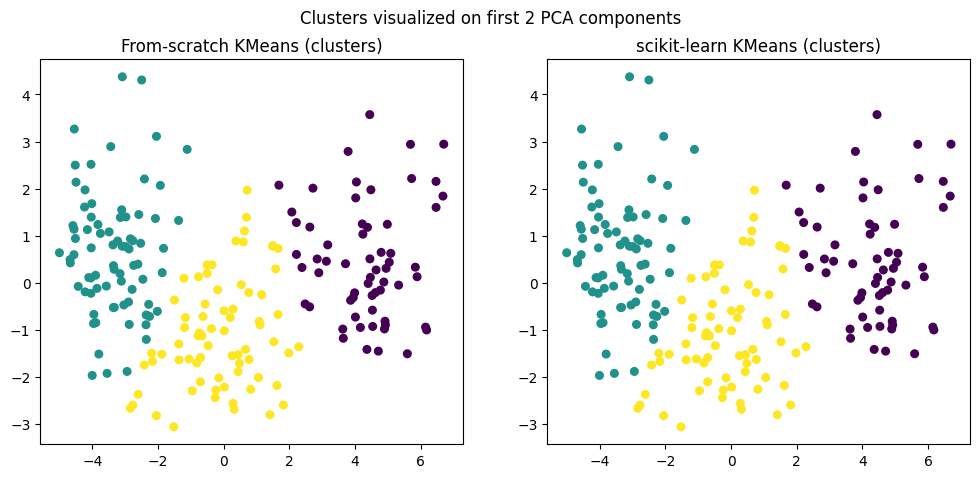

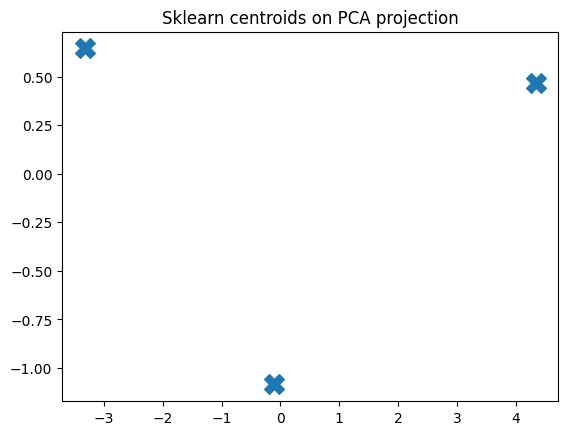

In [ ]:
# Bonus: Visualize clusters using the first two principal components (optional)
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca.fit_transform(X)

fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(X2[:,0], X2[:,1], c=labels_scratch, cmap='viridis', s=30)
axes[0].set_title('From-scratch KMeans (clusters)')
axes[1].scatter(X2[:,0], X2[:,1], c=labels_sklearn, cmap='viridis', s=30)
axes[1].set_title('scikit-learn KMeans (clusters)')
plt.suptitle('Clusters visualized on first 2 PCA components')
plt.show()

# Also show centroids projected to PCA space for sklearn (if needed)
centroid_proj = pca.transform(centers_sklearn)
plt.scatter(centroid_proj[:,0], centroid_proj[:,1], marker='X', s=200)
plt.title('Sklearn centroids on PCA projection')
plt.show()
